In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy
# import pyrealsense2 as rs
# %matplotlib widget

# root_dir = "C:\\Users\\Lenovo\\Desktop\\assemblyhelper"
root_dir = "/home/yuchen/projects/assemblyhelper"

In [2]:
# Load RGB and PCD raw datas
data_path = "assets/exp_data/raw_datas/part_space2.npy"
img_info = np.load(os.path.join(root_dir, data_path), allow_pickle=True)
color_data = img_info[()]['color']
point_data = img_info[()]['pointcloud']

In [3]:
# Visualize depth and RGB map
depth_map = cv2.normalize(point_data[:, :, 2], None, 0, 255, cv2.NORM_MINMAX)
depth_map = depth_map.astype(np.uint8)
depth_map = cv2.cvtColor(depth_map, cv2.COLOR_BGR2RGB)
color_map = cv2.cvtColor(color_data, cv2.COLOR_BGR2RGB)
# color_map = color_data

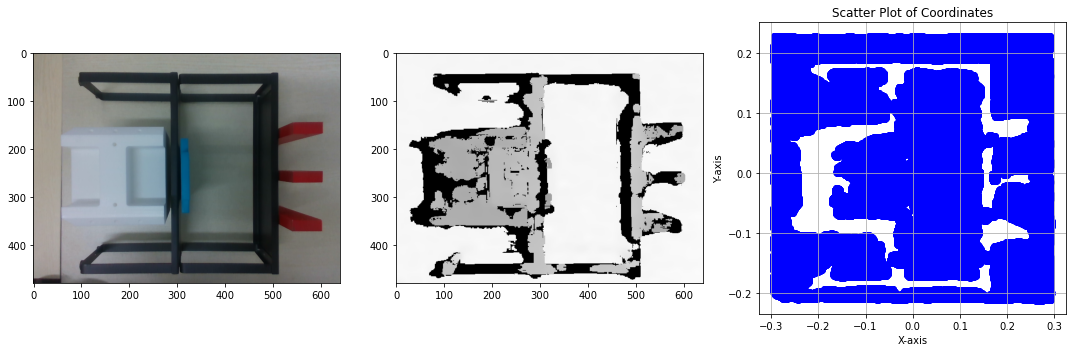

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ax = axes.ravel()
ax[0].imshow(color_map)
ax[1].imshow(depth_map)

# visualize xy coordinate
xy_data = point_data[..., :2].reshape((-1,2))
ax[2].scatter(xy_data[:, 0], -xy_data[:, 1], marker='o', color='blue')
ax[2].set_title('Scatter Plot of Coordinates')
ax[2].set_xlabel('X-axis')
ax[2].set_ylabel('Y-axis')
ax[2].grid(True)

plt.tight_layout()
plt.show()

In [5]:
# Load mask data
mask_path = "assets/exp_data/masks/part_space2.npy"
mask_info = np.load(os.path.join(root_dir, mask_path), allow_pickle=True)

In [20]:
# Extract mask region
obj_mask = mask_info[()]['signal']
projected_data = point_data[:, :, :2]
depth_data =  point_data[:, :, 2]

# filter by specific objs mask
masked_proj_cloud = projected_data[obj_mask != 0]
masked_depth = depth_data[obj_mask != 0]
# filter zero points
fliter_data = masked_proj_cloud[masked_depth != 0]
filter_depth = masked_depth[masked_depth != 0]
# print(filter_depth.shape)
# print(fliter_data.shape)
# filter outlier data
min_depth = np.min(filter_depth)
threshold = min_depth + 0.05
indices = np.where(filter_depth < threshold)[0]
fliter_data = fliter_data[indices]
filter_depth = filter_depth[indices]

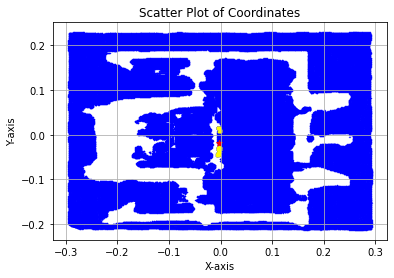

[-0.00307539  0.01794564] 0.36453745
[-0.00340819  0.01519118] 0.36453745
[-0.00310041  0.0294039 ] 0.36453745


In [23]:
# Get raw data & grasp center in point in PCD
xy_data = point_data[..., :2].reshape((-1,2))
plt.scatter(xy_data[:, 0], -xy_data[:, 1], marker='o', color='blue', s=0.1)

max_x, min_x = np.max(fliter_data[:, 0], axis=0), np.min(fliter_data[:, 0], axis=0)
max_y, min_y = np.max(fliter_data[:, 1], axis=0), np.min(fliter_data[:, 1], axis=0)
mean_xy1 = 1/2 * np.array([max_x+min_x, max_y+min_y])

mid_xy = np.median(fliter_data, axis=0)

mean_xy = np.mean(fliter_data, axis=0)
mean_z = np.mean(filter_depth, axis=0)
plt.scatter(fliter_data[:, 0], -fliter_data[:, 1], marker='o', color='yellow', s=0.1)
plt.scatter(mean_xy[0], -mean_xy[1], marker='*', color='red')

plt.title('Scatter Plot of Coordinates')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid(True)
plt.show()

print(mean_xy, mean_z)
print(mean_xy1, mean_z)
print(mid_xy, mean_z)

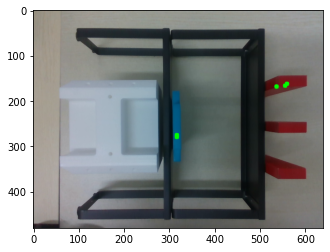

In [24]:
# Visualize grasp center in raw image
matching_indices = [0, 0]
min_distance = 1e10
for i in range(projected_data.shape[0]):
    for j in range(projected_data.shape[1]):
        # select center point only in masked region
        if obj_mask[i][j] == False:
            continue
        if depth_data[i][j] > 0.5:
            continue
        distance = np.linalg.norm(projected_data[i, j] - mean_xy)
        if distance < min_distance:
            min_distance = distance
            matching_indices = np.array([j, i])

# depth_to_color_extrinsics -> intrinsics_rgb (probably wrong)
# matching_indices = [562, 355]
# matching_indices = [591, 259]
# matching_indices = [572, 165]
# matching_indices = [341, 281]
# matching_indices = [201, 265]

# intrinsics_rgb only (probably right)
# matching_indices = [540, 356]
# matching_indices = [570, 260]
# matching_indices = [551, 165]
# matching_indices = [178, 262]
# matching_indices = [317, 279]

matching_indices = [556, 166]
matching_indices = [537, 168]
matching_indices = [560, 162]
matching_indices = [317, 275]


cv2.circle(color_map, matching_indices, radius=5, color=[0,255,0], thickness=-1)
plt.imshow(color_map)

In [9]:
# Visualize object's PCD
# %matplotlib inline
%matplotlib ipympl
# %matplotlib notebook
# %matplotlib widget 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

processed_data = copy.deepcopy(point_data[obj_mask != 0])
processed_data = processed_data[~np.any(processed_data == 0, axis=1)]
ax.scatter(processed_data[:, 0], processed_data[:, 1], processed_data[:, 2], c='b', marker='o', label='pcd')

grasp_center = point_data[matching_indices[1], matching_indices[0]]
ax.scatter(grasp_center[0], grasp_center[1], grasp_center[2], c='r', marker='o', s=500, label='grasp')

# ax.scatter(point_data[..., 0], -point_data[..., 1], point_data[..., 2], c='b', marker='o', label='grasp')


# 设置坐标轴标签
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# 显示图形
plt.show()

ModuleNotFoundError: No module named 'ipympl'

In [18]:
def visualize_grasp(center):
    bbox = np.array([[-50, 25], [50, 25], [-50, -25], [50, -25]])
    top_left = center + bbox[0]
    top_right = center + bbox[1]
    bottom_left = center + bbox[2]
    bottom_right = center + bbox[3]
    width_color = (13, 18, 130)
    height_color = (255, 108, 34)
    cv2.line(color_map, top_left, top_right, width_color,2)
    cv2.line(color_map, bottom_left, bottom_right, width_color,2)
    cv2.line(color_map, top_left, bottom_left, height_color,3)
    cv2.line(color_map, top_right, bottom_right, height_color,3)

In [19]:
# Visualize grasp pose in raw image
visualize_grasp(matching_indices)
plt.axis('off')
plt.imshow(color_map)
# grasp_save_path = "assets/exp_data/results/grasp_part2.jpg"
# plt.savefig(os.path.join(root_dir, grasp_save_path), bbox_inches='tight', pad_inches=0)

In [16]:
grasp_save_path = "assets/exp_data/results/grasp_part2.jpg"
cv2.imwrite(os.path.join(root_dir, grasp_save_path), cv2.cvtColor(color_map, cv2.COLOR_RGB2BGR))

True